In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

/var/folders/_7/ctdvqpn545g_11q0hy6r9n5h0000gn/T/ipykernel_14880/2359678944.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [5]:
all_data_table = pd.read_csv("gut_taxonomic_table.csv", low_memory=False)
metadata_table = pd.read_csv("sample_data.csv", low_memory=False)
display(Markdown(f"**Main Datatable:** {all_data_table.shape}"))
display(Markdown(f"**Metadata Datatable** {metadata_table.shape}"))


**Main Datatable:** (4850, 4682)

**Metadata Datatable** (4850, 755)

In [6]:
# columns = ['run_accession', 'attribute_alcohol_types_unspecified','attribute_alcohol_types_spiritshard_alcohol','attribute_alcohol_frequency','attribute_alcohol_consumption','attribute_alcohol_types_beercider','attribute_alcohol_types_white_wine','attribute_alcohol_types_sour_beers','attribute_alcohol_types_red_wine','attribute_vioscreen_alcohol_servings','attribute_vioscreen_alcohol','attribute_pm_lifestyle_change_how_change_in_alcohol_or_tobacco_use_ie_starting_stopping_or_changing_amount_consumed','attribute_alcohol_types']
columns = ['run_accession', 'attribute_alcohol_consumption', 'attribute_alcohol_frequency']
alco_metadata = metadata_table[columns]


In [7]:
# summarasized_bacteries_data['id'] = all_data_table['id']
summarasized_bacteries_data = all_data_table.iloc[:, :1].copy()
summarasized_bacteries_data['run_accession'] = all_data_table['sample'].str.split('_').str[1]
summarasized_bacteries_data['count'] = all_data_table.iloc[:, 2:].sum(axis=1)
summarasized_bacteries_data['median'] = all_data_table.iloc[:, 2:].replace(0, pd.NA).median(axis=1)

# display(all_data_table.iloc[:, 2:])
display(summarasized_bacteries_data['median'])
#
# data_table['run_accession'] = data_table['sample'].str.split('_').str[1]
# display(data_table['run_accession'])

0       27.0
1       23.0
2       36.0
3       27.5
4       34.5
        ... 
4845    34.0
4846    17.0
4847    24.0
4848    32.0
4849    33.5
Name: median, Length: 4850, dtype: object

In [8]:
data = summarasized_bacteries_data.merge(alco_metadata, on='run_accession')
display(data)

,Unnamed: 0,run_accession,count,median,attribute_alcohol_consumption,attribute_alcohol_frequency
0,5122,ERR4371625,13995,27.0,Yes,Rarely (a few times/month)
1,5123,ERR4371626,21134,23.0,No,Never
2,5124,ERR4371627,16117,36.0,Yes,Occasionally (1-2 times/week)
3,5125,ERR4371628,15930,27.5,No,Never
4,5126,ERR4371629,15138,34.5,No,Never
...,...,...,...,...,...,...
4845,9967,ERR6177040,28583,34.0,No,Never
4846,9968,ERR6177041,20714,17.0,No,Never
4847,9969,ERR6177042,31653,24.0,No,Never
4848,9970,ERR6177043,16198,32.0,No,Never


In [9]:
# checking all possible values
display(data.groupby('attribute_alcohol_consumption')['attribute_alcohol_consumption'].unique())

attribute_alcohol_consumption
No                            [No]
Unspecified          [Unspecified]
Yes                          [Yes]
not applicable    [not applicable]
not collected      [not collected]
not provided        [not provided]
Name: attribute_alcohol_consumption, dtype: object

In [10]:
# we need only known alcohol consumers
data2 = data.query('attribute_alcohol_consumption in ["Yes", "No"]')
# display(data['median'])

In [11]:
# checking data consitancy
display(data2.query('attribute_alcohol_consumption == "No" and attribute_alcohol_frequency != "Never"'))

display(data2.query('attribute_alcohol_consumption == "Yes"').groupby('attribute_alcohol_frequency')['attribute_alcohol_frequency'].unique())

,Unnamed: 0,run_accession,count,median,attribute_alcohol_consumption,attribute_alcohol_frequency


attribute_alcohol_frequency
Daily                                                    [Daily]
Occasionally (1-2 times/week)    [Occasionally (1-2 times/week)]
Rarely (a few times/month)          [Rarely (a few times/month)]
Regularly (3-5 times/week)          [Regularly (3-5 times/week)]
Name: attribute_alcohol_frequency, dtype: object

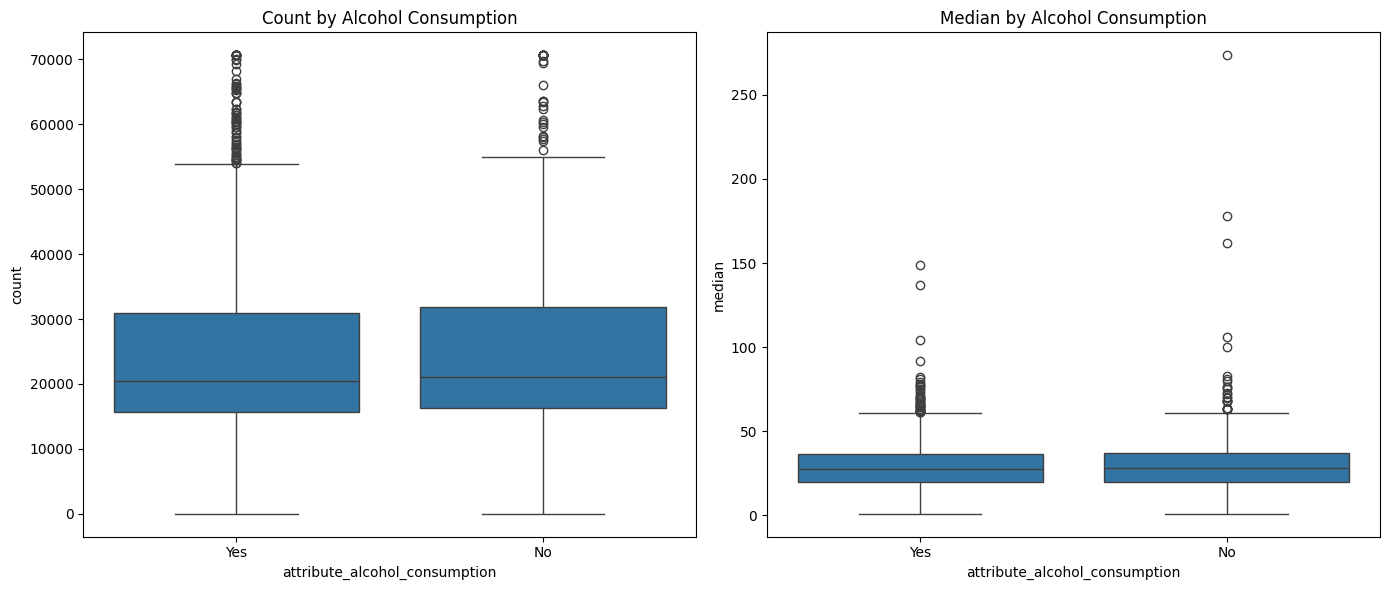

In [12]:
lower = data2['count'].quantile(0.01)
upper = data2['count'].quantile(0.99)
data2 = data2.copy()  # избегаем SettingWithCopyWarning
data2['count'] = data2['count'].clip(lower=lower, upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=data2, x='attribute_alcohol_consumption', y='count', ax=axes[0])
axes[0].set_title('Count by Alcohol Consumption')

sns.boxplot(data=data2, x='attribute_alcohol_consumption', y='median', ax=axes[1])
axes[1].set_title('Median by Alcohol Consumption')

plt.tight_layout()
plt.show()

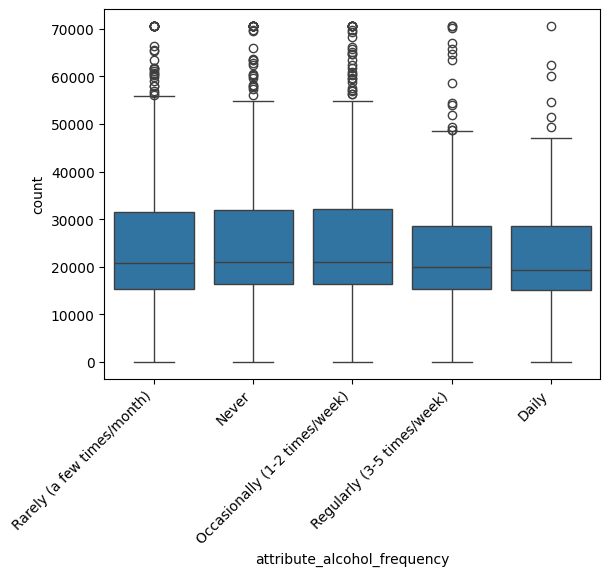

In [13]:
sns.boxplot(data=data2, x='attribute_alcohol_frequency', y='count')
# ax = sns.boxplot(data=data2, x='attribute_alcohol_frequency', y='median')
plt.xticks(rotation=45, ha='right')
plt.show()
pass

In [14]:
# going to check data about diets
# display(metadata_table.groupby('attribute_diet_type')['attribute_diet_type'].unique())
display(metadata_table.groupby('attribute_specialized_diet_exclude_refined_sugars')['attribute_specialized_diet_exclude_refined_sugars'].unique())

# for diet in all_diets:
#     display(Markdown(f"**{diet}**"))
#     res = metadata_table.groupby(diet)[diet].unique()
#     display(res)
#     display(type(res.iloc[0]))

attribute_specialized_diet_exclude_refined_sugars
FALSE                    [FALSE]
No                          [No]
TRUE                      [TRUE]
Unknown                [Unknown]
Unspecified        [Unspecified]
Yes                        [Yes]
false                    [false]
not collected    [not collected]
true                      [true]
Name: attribute_specialized_diet_exclude_refined_sugars, dtype: object

In [15]:
# display(metadata_table.groupby('attribute_specialized_diet_kosher')['attribute_specialized_diet_kosher'].unique())
strange_diet = ['attribute_pm_shared_who_nutritionistdietician','attribute_pm_lifestyle_change_how_change_in_diet_ie_taking_a_probiotic','attribute_diet','attribute_specialized_diet',]
all_diets = ['attribute_specialized_diet_i_do_not_eat_a_specialized_diet', 'attribute_specialized_diet_exclude_refined_sugars','attribute_specialized_diet_modified_paleo_diet','attribute_specialized_diet_exclude_dairy','attribute_specialized_diet_fodmap','attribute_specialized_diet_raw_food_diet','attribute_specialized_diet_kosher','attribute_lowgrain_diet_type','attribute_specialized_diet_other_restrictions_not_described_here','attribute_specialized_diet_halaal','attribute_specialized_diet_paleo_diet_or_primal_diet','attribute_specialized_diet_exclude_nightshades','attribute_specialized_diet_unspecified','attribute_specialized_diet_paleodiet_or_primal_diet', 'attribute_specialized_diet_westenprice_or_lowgrain_low_processed_food_diet']


# those are the same diet for sure, merging as one 'attribute_specialized_diet_westenprice_or_lowgrain_low_processed_food_diet' name
# 'attribute_specialized_diet_westenprice_or_other_lowgrain_low_processed_food_diet'
# 'attribute_specialized_diet_weston_price_or_other_low_grain_low_processed_food_diet',
# 'attribute_specialized_diet_westenprice_or_other_lowgrain_low_processed_fo',

metadata_table['attribute_specialized_diet_westenprice_or_lowgrain_low_processed_food_diet'] = (
    metadata_table['attribute_specialized_diet_westenprice_or_other_lowgrain_low_processed_food_diet']
        .fillna(metadata_table['attribute_specialized_diet_weston_price_or_other_low_grain_low_processed_food_diet'])
        .fillna(metadata_table['attribute_specialized_diet_westenprice_or_other_lowgrain_low_processed_fo'])
)            

extra_diets_cols = ('attribute_diet_type', )

# for diet in all_diets:
#     display(Markdown(f"**{diet}**"))
#     res = metadata_table.groupby(diet)[diet].unique()
#     display(res)
#     display(type(res.iloc[0]))



# We're going to change to one representation of Python's True / False + None
# "False", "FALSE", "false", "No", "no", "NO" -> False

fixes = [[{"true", "yes"}, "yes"], 
         [{"false", "no"}, "no"], 
         [{"unknown", "unspecified", "not collected", "not provided", "not applicable ", "None"}, "unknown"]
        ]

try:
    for diet in all_diets:
        for fix in fixes:
            mask = (
                metadata_table[diet]
                .astype(str)
                .str.lower()
                .isin(fix[0])
            )
    
            metadata_table.loc[mask, diet] = fix[1]
except Exception as e:
    display(e, mask, diet, fix)


# for diet in all_diets:
#     display(Markdown(f"**{diet}**"))
#     res = metadata_table.groupby(diet, dropna=False)[diet].unique()
#     display(res)
#     display(type(res.iloc[0]))


    

In [16]:
data = summarasized_bacteries_data.merge(metadata_table, on='run_accession')


df_long = data.melt(
    id_vars='count',
    value_vars=all_diets,
    var_name='attribute',
    value_name='value'
)
# sns.catplot(
#     data=df_long,
#     x='value',
#     y='count',
#     col='attribute',
#     kind='box',
#     col_wrap=2,
#     sharey=False
# )
pass

diets_table = metadata_table[list(all_diets) + ['run_accession']]
# display(diets_table)

data = bacteries_data.merge(diets_table, on='run_accession')


df_long = data.melt(
    id_vars=['run_accession'] + list(all_diets),
    var_name='taxa',
    value_name='abundance'
)
display(df_long[0:1])

# We check using "bird's view" and understand that there is no much difference on graphs, so total count of bacteria doesn't show any interesting results

NameError: name 'bacteries_data' is not defined

In [ ]:
display(df_long)

In [ ]:
# bacteries_data = all_data_table.iloc[:, :1].copy()
bacteries_data = all_data_table.copy()
bacteries_data['run_accession'] = all_data_table['sample'].str.split('_').str[1]
bacteries_data = bacteries_data.drop(columns=['sample', 'Unnamed: 0'])
# bacteries_data += all_data_table.iloc[:, :2].copy()

# display(metadata_table)
diets_table = metadata_table[list(all_diets) + ['run_accession']]
# display(diets_table)

data = bacteries_data.merge(diets_table, on='run_accession')


df_long = data.melt(
    id_vars=['run_accession'] + list(all_diets),
    var_name='taxa',
    value_name='abundance'
)



In [ ]:
display(df_long['abundance'].max())
display(df_long.shape)

In [ ]:
# display(df_long)
# display(df_long['run_accession'].unique())
# display(metadata_table)

In [ ]:
top_taxa = (df_long.groupby('taxa')['abundance']
    # .mean()
    .median()
    .sort_values(ascending=False)
    .head(10)
    .index )
display(top_taxa)

In [ ]:
for diet in all_diets[:1]:
    g = sns.catplot(
        data=df_long[df_long['taxa'].isin(top_taxa)],
        x=diet,
        y='abundance',
        col='taxa',
        kind='box',
        col_wrap=1,
        hue=diet,
        legend=True,
        sharey=False
    )
    
    # Показать x-метки на каждом subplot
    for ax in g.axes.flat:
        ax.tick_params(labelbottom=True)  # принудительно показать метки
        for label in ax.get_xticklabels():
            label.set_rotation(30)
            label.set_ha('right')
        ax.set_xlabel(diet)  # подпись оси X
    
    # Переместить легенду наружу
    g.legend.set_bbox_to_anchor((1.05, 0.5))
    g.legend.set_title(diet)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# plan:
# going to take 1 diet for less data -> better visibility, 
# group bacteria by Genus (adding sample number for species in one genus)
# should we use the same type of a graph, or try an other one for better visibility of large amount of the data?

def to_family(taxa):
    return ".".join(taxa.split(".")[:5])

df_family = all_data_table.copy()
df_family['run_accession'] = df_family['sample'].str.split('_').str[1]
na_cols = [col for col in df_family.columns if 'NA' in col]
df_family = df_family.drop(columns=['sample', 'Unnamed: 0'] + na_cols)
df_family.columns = [to_family(col) for col in df_family.columns]
df_family = df_family.T.groupby(level=0).sum().T

# display(df_family)


In [ ]:
diets_table = metadata_table[list(all_diets) + ['run_accession']]
# display(diets_table)

data = df_family.merge(diets_table, on='run_accession')


df_long = data.melt(
    id_vars=['run_accession'] + list(all_diets),
    var_name='taxa',
    value_name='abundance'
)

In [ ]:
display(df_long)

In [ ]:
colors = sns.color_palette('Paired').as_hex()
palette = {}
for diet in all_diets:
    # if 'meat' not in diet: continue
    # diet = 'attribute_specialized_diet_halaal'
    top_ = df_long.query(f'{diet} == "yes"').sort_values('abundance', ascending=False)[:10]
    for t in top_['taxa']:
        if t not in palette:
            palette[t] = colors.pop()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    
    sns.barplot(data=top_, x='taxa', y='abundance', palette=palette, hue='taxa', legend=True)
    
    ax.set_xticks([])       # убирает подписи по оси X
    ax.set_xlabel('')       # убирает подпись "taxa" под осью
    
    # легенда под графиком
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),  # ниже графика
        ncol=1,
        title=diet
    
    )
    
    plt.tight_layout()
    plt.show()
    pass
# (df_long.query('attribute_specialized_diet_halaal == "yes"').sort_values('abundance', ascending=False)[:10]['taxa'])


In [ ]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.patches import Patch

# top-10 таксонов на диету (где diet == "yes"), как в исходной ячейке
diet_tops = {}
for diet in all_diets:
    top_ = (df_long.query(f'{diet} == "yes"')
                 .groupby('taxa', as_index=False)['abundance'].median()   # или .mean()
                 .sort_values('abundance', ascending=False)
                 .head(10))
    if not top_.empty:
        diet_tops[diet] = top_.reset_index(drop=True)

# единая палитра: один цвет = один таксон на всех диетах
base_colors = (sns.color_palette('Paired').as_hex()
               + sns.color_palette('Set2').as_hex()
               + sns.color_palette('Set3').as_hex()
               + sns.color_palette('tab20').as_hex())
palette = {}
for top_ in diet_tops.values():
    for t in top_['taxa']:
        if t not in palette:
            palette[t] = base_colors[len(palette) % len(base_colors)]


In [ ]:
%matplotlib inline

fig = plt.figure(figsize=(18, 9))
ax = fig.add_subplot(111, projection='3d')

bar_w, bar_d = 0.6, 0.5 #0.8, 0.6

for y_idx, (diet, top_) in enumerate(diet_tops.items()):
    xs = np.arange(len(top_), dtype=float)
    ys = np.full_like(xs, y_idx, dtype=float) - bar_d / 2
    zs = np.zeros_like(xs)
    dx = np.full_like(xs, bar_w)
    dy = np.full_like(xs, bar_d)
    dz = top_['abundance'].to_numpy(dtype=float)
    bar_colors = [palette[t] for t in top_['taxa']]
    ax.bar3d(xs, ys, zs, dx, dy, dz, color=bar_colors, shade=True)

ax.set_yticks(range(len(diet_tops)))
ax.set_yticklabels(
    [d.replace('attribute_specialized_diet_', '').replace('attribute_', '').replace('_', ' ')
     for d in diet_tops],
    fontsize=12,
    ha='left',
    va='bottom'
)
ax.set_xticks([])
ax.set_xlabel('top taxa (rank)')
# ax.set_ylabel('diet')
ax.set_zlabel('abundance')
ax.view_init(elev=45, azim=-40)

ax.bar3d(xs, ys, zs, dx, dy, dz,
         color=bar_colors, shade=True,
         alpha=0.85,        # лёгкая прозрачность помогает визуально
         zsort='average')   # сортировка по средней глубине

handles = [Patch(color=c, label=t) for t, c in palette.items()]
ax.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    fontsize=7,
    title='taxa',
)

# plt.tight_layout()
plt.show()
pass

In [ ]:
# Completely AI generated previous graph generation to check if it can be dynamically anymated
import plotly.graph_objects as go
diet_tops = {}

for diet in all_diets:
    top_ = (
        df_long.query(f'{diet} == "yes"')
        .groupby('taxa', as_index=False)['abundance']
        .median()
        .sort_values('abundance', ascending=False)
        .head(10)
    )

    if not top_.empty:
        diet_tops[diet] = top_.reset_index(drop=True)

# human friendly diets names
diet_names = {
    diet: (
        diet.replace('attribute_specialized_diet_', '')
            .replace('attribute_', '')
            .replace('_', ' ')
    )
    for diet in diet_tops
}

# same colors as on the previous graph
base_colors = (
    sns.color_palette('Paired').as_hex()
    + sns.color_palette('Set2').as_hex()
    + sns.color_palette('Set3').as_hex()
    + sns.color_palette('tab20').as_hex()
)

palette = {}

for top_ in diet_tops.values():
    for t in top_['taxa']:
        if t not in palette:
            palette[t] = base_colors[len(palette) % len(base_colors)]


fig = go.Figure()

bar_w = 0.55
bar_d = 0.55

trace_diets = []

for y_idx, (diet, top_) in enumerate(diet_tops.items()):
    diet_name = diet_names[diet]

    for rank, row in top_.iterrows():
        taxa = row['taxa']
        abundance = row['abundance']

        x0 = rank
        y0 = y_idx

        x = [
            x0, x0 + bar_w, x0 + bar_w, x0,
            x0, x0 + bar_w, x0 + bar_w, x0
        ]
        y = [
            y0, y0, y0 + bar_d, y0 + bar_d,
            y0, y0, y0 + bar_d, y0 + bar_d
        ]
        z = [
            0, 0, 0, 0,
            abundance, abundance, abundance, abundance
        ]

        i = [0, 0, 0, 1, 2, 3, 4, 4, 5, 6, 7, 4]
        j = [1, 2, 3, 5, 6, 7, 5, 6, 6, 7, 4, 7]
        k = [2, 3, 0, 6, 7, 4, 6, 7, 2, 3, 0, 3]

        fig.add_trace(
            go.Mesh3d(
                x=x,
                y=y,
                z=z,
                i=i,
                j=j,
                k=k,
                color=palette[taxa],
                opacity=0.85,
                name=diet_name,
                legendgroup=diet_name,
                showlegend=False,
                customdata=[[diet_name, taxa, rank + 1, abundance]] * 8,
                hovertemplate=(
                    "<b>Diet:</b> %{customdata[0]}<br>"
                    "<b>Taxa:</b> %{customdata[1]}<br>"
                    "<b>Rank:</b> %{customdata[2]}<br>"
                    "<b>Abundance:</b> %{customdata[3]:.2f}"
                    "<extra></extra>"
                )
            )
        )

        trace_diets.append(diet)


# "All" button
buttons = []

buttons.append(
    dict(
        label="All diets",
        method="restyle",
        args=[{"opacity": [0.85] * len(fig.data)}]
    )
)

# кнопки для каждой диеты
for selected_diet in diet_tops.keys():
    opacities = [
        0.95 if d == selected_diet else 0.08
        for d in trace_diets
    ]

    buttons.append(
        dict(
            label=diet_names[selected_diet],
            method="restyle",
            args=[{"opacity": opacities}]
        )
    )


# legend colors 
diet_legend_colors = sns.color_palette("husl", len(diet_tops)).as_hex()

diet_legend_text = "<br>".join(
    [
        (
            f"<span style='color:{diet_legend_colors[i]}; font-size:16px'>●</span> "
            f"<b>D{i+1}</b>: {diet_names[diet]}"
        )
        for i, diet in enumerate(diet_tops.keys())
    ]
)


fig.update_layout(
    title="Top taxa by diet",
    width=1550,
    height=850,

    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.02,
            y=1.08,
            xanchor="left",
            yanchor="top",
            bgcolor="white",
            bordercolor="lightgray",
            borderwidth=1
        )
    ],

    annotations=[
        dict(
            text="<b>Diet legend</b><br><br>" + diet_legend_text,
            x=1.03,
            y=0.95,
xref="paper",
            yref="paper",
            showarrow=False,
            align="left",
            bordercolor="lightgray",
            borderwidth=1,
            borderpad=8,
            bgcolor="white",
            font=dict(size=12)
        )
    ],

    scene=dict(
        xaxis=dict(
            title="Top taxa rank",
            tickmode="array",
            tickvals=list(range(10)),
            ticktext=[str(i) for i in range(1, 11)]
        ),

        yaxis=dict(
            title="Diet",
            tickmode="array",
            tickvals=list(range(len(diet_tops))),
            ticktext=[
                f"D{i+1}" for i in range(len(diet_tops))
            ]
        ),

        zaxis=dict(title="Abundance"),

        camera=dict(
            eye=dict(x=1.45, y=-1.8, z=1.25)
        ),

        dragmode=False
    ),

    margin=dict(l=0, r=390, t=90, b=0)
)

fig.show()

In [ ]:
# Control group microbiom, so we can check if there are major differences between people who wrote a special diet 
# and people who didn't

# 1. Определяем контрольную колонку
control_col = 'attribute_specialized_diet_i_do_not_eat_a_specialized_diet'

# 2. Запускаем цикл по всем диетам
for diet_to_compare in all_diets:
    # Пропускаем саму контрольную колонку, чтобы не сравнивать её с собой
    if diet_to_compare == control_col:
        continue
    
    # Фильтруем данные для текущей диеты и контроля
    comparison_df = df_long[
        (df_long[diet_to_compare] == "yes") | 
        (df_long[control_col] == "yes")
    ].copy()

    # Проверяем, есть ли вообще люди на этой диете
    if comparison_df[comparison_df[diet_to_compare] == "yes"].empty:
        print(f"Пропускаем {diet_to_compare}: нет данных (0 образцов с 'yes')")
        continue

    # Создаем метки групп
    comparison_df['group'] = "No Special Diet"
    comparison_df.loc[comparison_df[diet_to_compare] == "yes", 'group'] = "On Diet"

    # Выбираем ТОП-5 таксонов именно для этого сравнения
    current_top_taxa = (comparison_df.groupby('taxa')['abundance']
                        .median()
                        .sort_values(ascending=False)
                        .head(5).index.tolist())

    final_df = comparison_df[comparison_df['taxa'].isin(current_top_taxa)]

    # 3. Визуализация
    if not final_df.empty:
        g = sns.catplot(
            data=final_df,
            x='group',
            y='abundance',
            col='taxa',
            hue='group',
            kind='box',
            col_wrap=3,
            sharey=False,
            palette='Set1',
            showfliers=False,  # УБИРАЕМ ВЫБРОСЫ
            aspect=1.2,
            legend=False
        )

        # Добавляем подписи ко всем графикам и настраиваем отступы
        for ax in g.axes.flat:
            ax.tick_params(labelbottom=True)
            title = ax.get_title().replace('taxa = ', '')
            ax.set_title(title, fontsize=8, pad=10)

        # Настройка общего заголовка для текущей диеты
        clean_name = diet_to_compare.replace("attribute_specialized_diet_", "").replace("_", " ")
        g.fig.suptitle(f'Comparison: {clean_name.upper()} vs Control', fontsize=14, fontweight='bold', y=1.05)
        
        plt.subplots_adjust(hspace=0.7, wspace=0.3)
        plt.show()



In [ ]:
for diet_to_compare in all_diets:
    # Пропускаем саму контрольную колонку, чтобы не сравнивать её с собой
    if diet_to_compare == control_col:
        continue
    
    # Фильтруем данные для текущей диеты и контроля
    comparison_df = df_long[
        (df_long[diet_to_compare] == "yes") | 
        (df_long[control_col] == "yes")
    ].copy()

    # Проверяем, есть ли вообще люди на этой диете
    if comparison_df[comparison_df[diet_to_compare] == "yes"].empty:
        print(f"Пропускаем {diet_to_compare}: нет данных (0 образцов с 'yes')")
        continue

    # Создаем метки групп
    comparison_df['group'] = "No Special Diet"
    comparison_df.loc[comparison_df[diet_to_compare] == "yes", 'group'] = "On Diet"
    
    # Выбираем DOWN-5 таксонов именно для этого сравнения
    current_top_taxa = (comparison_df.groupby('taxa')['abundance']
                        .median()
                        .sort_values(ascending=True)
                        .head(5).index.tolist())

    final_df = comparison_df[comparison_df['taxa'].isin(current_top_taxa)]

    # 3. Визуализация
    if not final_df.empty:
        g = sns.catplot(
            data=final_df,
            x='group',
            y='abundance',
            col='taxa',
            hue='group',
            kind='box',
            col_wrap=3,
            sharey=False,
            palette='Set1',
            showfliers=False,  # УБИРАЕМ ВЫБРОСЫ
            aspect=1.2,
            legend=False
        )

        # Добавляем подписи ко всем графикам и настраиваем отступы
        for ax in g.axes.flat:
            ax.tick_params(labelbottom=True)
            title = ax.get_title().replace('taxa = ', '')
            ax.set_title(title, fontsize=8, pad=10)

        # Настройка общего заголовка для текущей диеты
        clean_name = diet_to_compare.replace("attribute_specialized_diet_", "").replace("_", " ")
        g.fig.suptitle(f'Comparison: {clean_name.upper()} vs Control', fontsize=14, fontweight='bold', y=1.05)
        
        plt.subplots_adjust(hspace=0.7, wspace=0.3)
        plt.show()